<a href="https://colab.research.google.com/github/Mrinal0044/Machine-Learning/blob/main/Feature_scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Feature engineering-** converting raw data to extract valuable features

ski-kit library only handles numeric data and does not accept missing values.

What is feature scaling? Technique to standardize the independent features present in the data in a fixed range.
2 TYPES-
1. Standardization
2. Normalization
      -minmaxscaled
      -robustscaled

STANDARDIZATION (z-score normalization)

In [ ]:
import numpy as np #linear algebra
import pandas as pd #data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df= pd.read_csv('/content/Social_Network_Ads .csv')

In [ ]:
df= df.iloc[:, 2:]

In [ ]:
df.sample(5)

,Age,EstimatedSalary,Purchased
358,40,71000,1
48,30,135000,1
159,32,135000,1
346,53,72000,1
200,35,39000,0


train test split

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(df.drop('Purchased', axis=1), df['Purchased'], random_state=0)
x_train.shape, x_test.shape

((300, 2), (100, 2))

standard scaler

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

#fit the scaler to the train set, it will learn the parameters
scaler.fit(x_train)

#transform train and test sets
x_train_scaled= scaler.transform(x_train)
x_test_scaled= scaler.transform(x_test)

In [ ]:
scaler.mean_ #first is the mean of age , second is the mean of salary

array([3.81266667e+01, 6.95833333e+04])

now the problem is that we have given dataframe and it is returning us numpy array. so we need it transform array to dataframe for better understanding

In [ ]:
x_train_scaled= pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled= pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [ ]:
(x_train_scaled)

,Age,EstimatedSalary
0,0.581649,-0.886707
1,-0.606738,1.461738
2,-0.012544,-0.567782
3,-0.606738,1.896635
4,1.373907,-1.408584
...,...,...
295,0.977778,-1.147645
296,-0.903834,-0.770734
297,-0.210609,-0.509796
298,-1.101899,-0.451810


now compare the mean and sd

In [ ]:
np.round(x_train.describe(),1)

,Age,EstimatedSalary
count,300.0,300.0
mean,38.1,69583.3
std,10.1,34548.5
min,18.0,15000.0
25%,30.8,43000.0
50%,38.0,69500.0
75%,46.0,88000.0
max,60.0,150000.0


In [ ]:
np.round(x_train_scaled.describe(),1)

,Age,EstimatedSalary
count,300.0,300.0
mean,0.0,0.0
std,1.0,1.0
min,-2.0,-1.6
25%,-0.7,-0.8
50%,-0.0,-0.0
75%,0.8,0.5
max,2.2,2.3


EFFECT OF SCALING

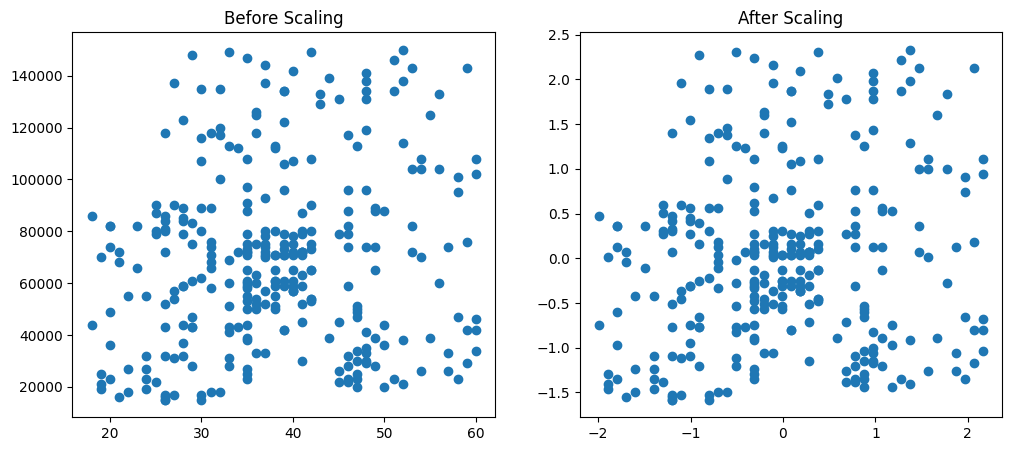

In [ ]:
fig, (ax1, ax2)= plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title('Before Scaling')
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'])
ax2.set_title('After Scaling')
plt.show()

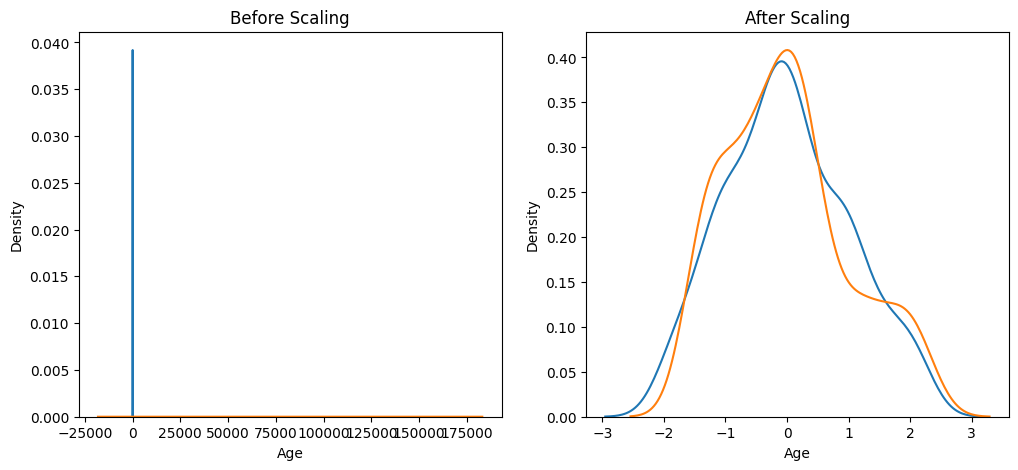

In [ ]:
fig, (ax1, ax2)= plt.subplots(ncols=2, figsize=(12,5))

#before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x=x_train['Age'], ax=ax1)
sns.kdeplot(x=x_train['EstimatedSalary'], ax=ax1)

#after scaling
ax2.set_title('After Scaling')
sns.kdeplot(x=x_train_scaled['Age'], ax=ax2)
sns.kdeplot(x=x_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

the above graph is a pdf (probability density function)

COMPARISON OF DISTRIBUTION

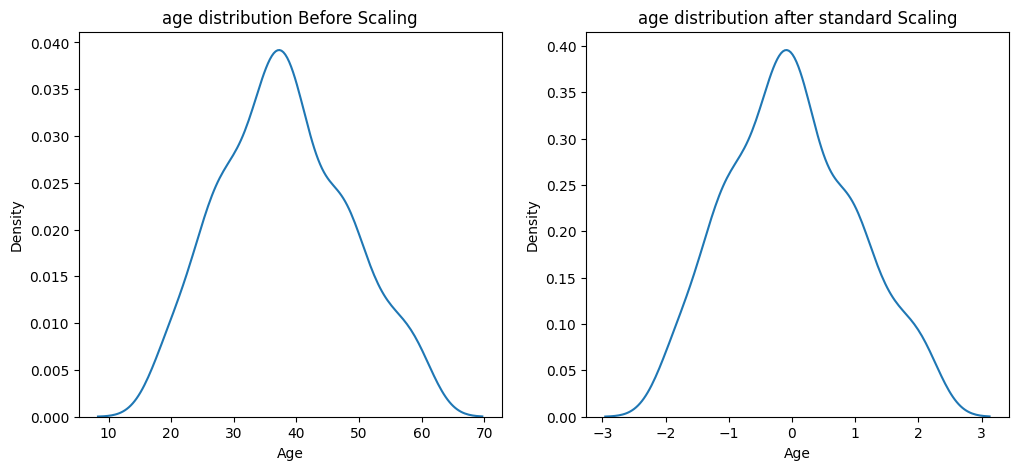

In [ ]:
fig, (ax1, ax2)= plt.subplots(ncols=2, figsize=(12,5))

#BEFORE SCALING
ax1.set_title('age distribution Before Scaling')
sns.kdeplot(x=x_train['Age'], ax=ax1)

#AFTER SCALING
ax2.set_title('age distribution after standard Scaling')
sns.kdeplot(x=x_train_scaled['Age'], ax=ax2)

plt.show()

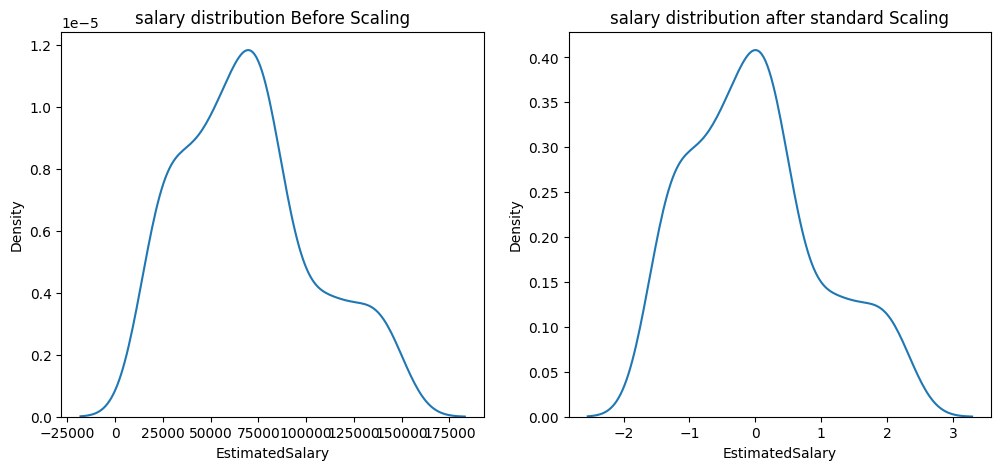

In [ ]:
fig, (ax1, ax2)= plt.subplots(ncols=2, figsize=(12,5))

#BEFORE SCALING
ax1.set_title('salary distribution Before Scaling')
sns.kdeplot(x=x_train['EstimatedSalary'], ax=ax1)

#AFTER SCALING
ax2.set_title('salary distribution after standard Scaling')
sns.kdeplot(x=x_train_scaled['EstimatedSalary'], ax=ax2)

plt.show()

so the shape of the curve and other graphs remain same but the scale changes

WHY SCALING IS IMPORTANT?



In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
lr= LogisticRegression()
lr_scaled= LogisticRegression() #obj of LogisticRegression

In [ ]:
lr.fit(x_train, y_train)
lr_scaled.fit(x_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred= lr.predict(x_test)
y_pred_scaled= lr_scaled.predict(x_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
print("actual",accuracy_score(y_test,y_pred))
print("scaled",accuracy_score(y_test,y_pred_scaled))

actual 0.89
scaled 0.89
